In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\MICROSOFT\.cache\kagglehub\datasets\mlg-ulb\creditcardfraud\versions\3


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, auc

import shap

In [3]:
path_to_dataset = path + "/creditcard.csv"
df = pd.read_csv(path_to_dataset)
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


the `Time` column is unique and we can drop it

In [4]:
df.drop("Time", axis=1, inplace=True)

In [5]:
print(df.shape)

(284807, 30)


In [6]:
print(df["Class"].value_counts())

Class
0    284315
1       492
Name: count, dtype: int64


the dataset is highly imbalanced, fraud cases are rare

In [7]:
print(df.isna().sum())

V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


## Data Preprocessing

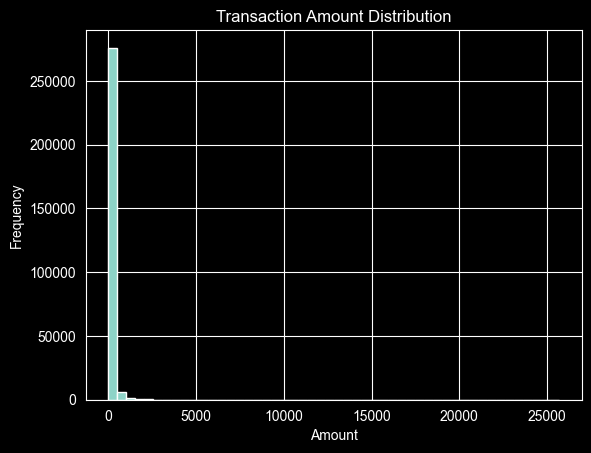

In [8]:
# amout distribution
plt.hist(df["Amount"], bins=50)
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

the amount distribution is right skewed, we can apply log transformation to reduce skewness

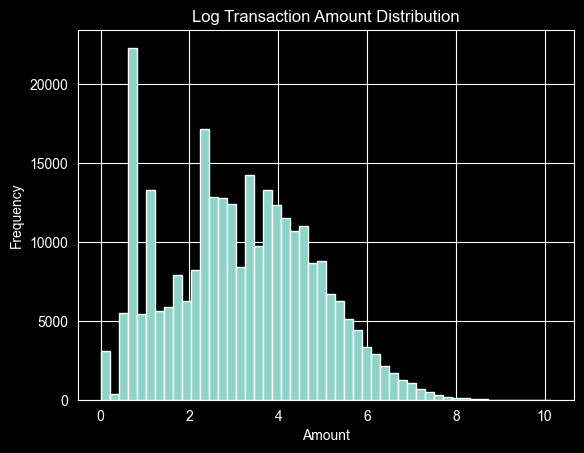

In [9]:
# log transform the amount
df["LogAmount"] = np.log1p(df["Amount"])
# drop original amount column
df.drop("Amount", axis=1, inplace=True)
plt.hist(df["LogAmount"], bins=50)
plt.title("Log Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

In [10]:
# scale the log amount data
df["scaled_amount"] = StandardScaler().fit_transform(df[["LogAmount"]])

# Model Training

In [ ]:
# train test split

In [11]:
X = df.drop(["Class", "LogAmount"], axis=1)
y = df["Class"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Handle imbalance

In [12]:
smote = SMOTE()
X_train, y_train = smote.fit_resample(X_train, y_train)

In [13]:
# check new class distribution
print(pd.Series(y_train).value_counts())

Class
0    227451
1    227451
Name: count, dtype: int64


try the following models:
- Logistic Regression
- Random Forest
- Isolation Forest
- XGBoost

In [23]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    # Note: Random Forest took so much time in training but got good recall so will be commented here and can be uncommented if you want to try it out, but be prepared for a long training time (more than 2 hours in shap explanation)
    # "Random Forest": RandomForestClassifier(n_estimators=100),
    "Isolation Forest": IsolationForest(contamination=0.01, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric="logloss")
}

# Focus on:
# Recall (catch fraud)
# Precision (avoid false alarms)

for name, model in models.items():
    print(f"Training {name}...")
    if name == "Isolation Forest":
        model.fit(X_train)
        y_pred = model.predict(X_test)
        y_pred = np.where(y_pred == -1, 1, 0)  # Convert to binary labels
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    print(f"Results for {name}:")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    if name != "Isolation Forest":
        roc_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
        print(f"ROC AUC: {roc_auc:.4f}")
    print("-" * 50)

Training Logistic Regression...
Results for Logistic Regression:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.10        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.98     56962

Confusion Matrix:
[[55330  1534]
 [    8    90]]
ROC AUC: 0.9695
--------------------------------------------------
Training Random Forest...
Results for Random Forest:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.86      0.81      0.83        98

    accuracy                           1.00     56962
   macro avg       0.93      0.90      0.92     56962
weighted avg       1.00      1.00      1.00     56962

Confusion Matrix:
[[56851    13]
 [   19    79]]
ROC AUC: 0.9729
-----------------------------------------------

C:\Users\MICROSOFT\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:45:32] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Results for XGBoost:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.72      0.89      0.80        98

    accuracy                           1.00     56962
   macro avg       0.86      0.94      0.90     56962
weighted avg       1.00      1.00      1.00     56962

Confusion Matrix:
[[56831    33]
 [   11    87]]
ROC AUC: 0.9751
--------------------------------------------------


## Interpretation:

- Logistic Regression -> catches fraud but too many false alarms
- Random Forest -> very balanced
- XGBoost -> better recall than RF but lower precision

Random Forest provides the best balance between precision and recall, making it suitable for fraud detection where both false positives and false negatives matter., but it takes a long time to train, XGBoost is a good alternative with better recall but more false positives.

In [14]:
best_model = XGBClassifier(use_label_encoder=False, eval_metric="logloss")
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred))

C:\Users\MICROSOFT\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [05:43:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.72      0.87      0.79        98

    accuracy                           1.00     56962
   macro avg       0.86      0.93      0.89     56962
weighted avg       1.00      1.00      1.00     56962



In [15]:
# visualize confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Confusion Matrix:
[[56831    33]
 [   13    85]]


## Explain model predictions

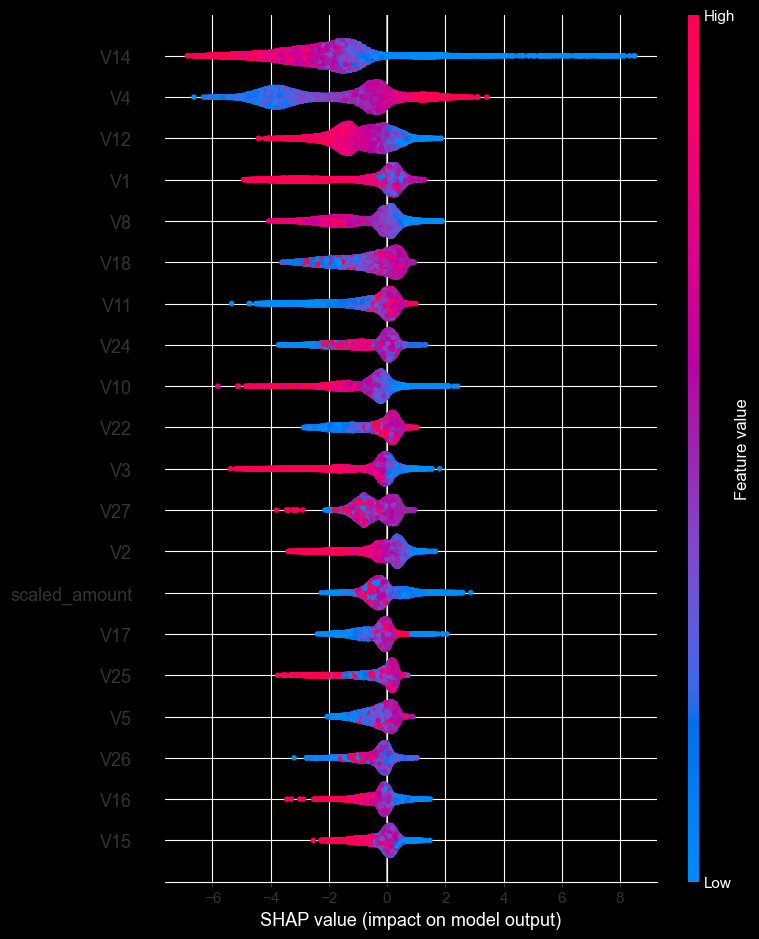

In [17]:
# warning: takes so long to run (more then 1 hour)
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)

## Key Insights
- **V14 is the most important feature** by a wide margin. High values of V14 (red) push SHAP scores strongly positive (toward fraud), while low values (blue) spread broadly to the right — an unusual but meaningful pattern worth investigating.

- **V4 and V12** are the second and third most influential features. Both show clear red/blue separation, indicating strong directional effects depending on feature magnitude.

- **V1 and V8** have moderate importance, with their distributions centered slightly left of zero, suggesting they tend to reduce fraud probability on average.

- **scaled_amount** (the transaction amount) has relatively low importance here, ranking 14th — meaning raw transaction size is less predictive than the PCA-derived V-features in this model.

- **Features V15–V26** (bottom of the plot) have narrow, tightly centered distributions, indicating minimal influence on model predictions.

## Explain one fraud prediction

In [25]:
shap.force_plot(
    explainer.expected_value,
    shap_values[1],
    X_test.iloc[0]
)

In [26]:
import pickle
pickle.dump(best_model, open("model/model.pkl", "wb"))